CNN

In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
import os
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D
import warnings
warnings.filterwarnings("ignore")

In [4]:
os.chdir(r"Data")

In [5]:
os.getcwd()

'C:\\Users\\lenovo\\Data'

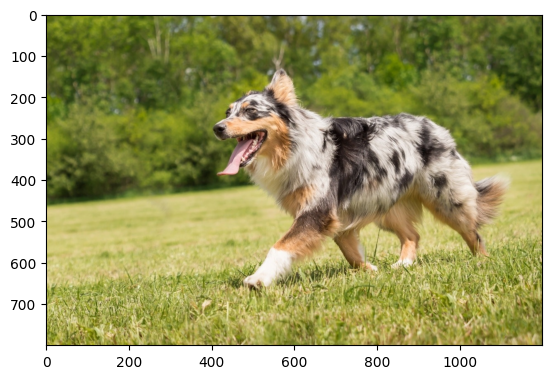

In [7]:
img = image.load_img("training/dog/3.jpeg")
plt.imshow(img)

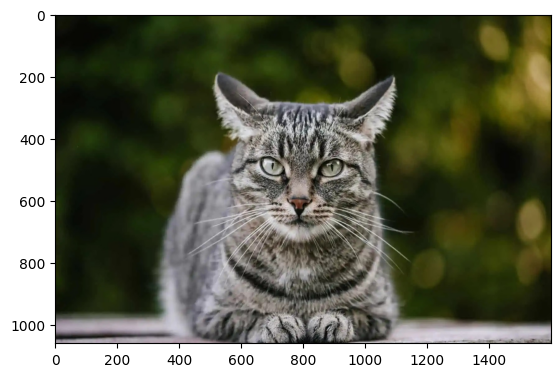

In [8]:
img = image.load_img("testing/1.jpeg")
plt.imshow(img)

In [12]:
train = ImageDataGenerator(rescale= 1/255)
validation = ImageDataGenerator(rescale= 1/255)

In [13]:
tr_location = r"training"
val_location = r"Validation"

In [14]:
train_data = train.flow_from_directory(tr_location,
                                      target_size=(200,200),
                                      batch_size= 3,
                                      class_mode= "binary")
valid_data = validation.flow_from_directory(val_location,
                                      target_size=(200,200),
                                      batch_size= 3,
                                      class_mode= "binary")

Found 16 images belonging to 2 classes.
Found 8 images belonging to 2 classes.


In [15]:
train_data.class_indices

{'cat': 0, 'dog': 1}

In [16]:
model = tf.keras.models.Sequential([

    tf.keras.layers.Conv2D(16,(3,3),activation="relu",input_shape=(200,200,3)),
    tf.keras.layers.MaxPool2D(2,2),

    tf.keras.layers.Conv2D(32,(3,3),activation="relu"),
    tf.keras.layers.MaxPool2D(2,2),

    tf.keras.layers.Conv2D(64,(3,3), activation="relu"),
    tf.keras.layers.MaxPool2D(2,2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(512,activation="relu"),

    tf.keras.layers.Dense(1,activation="sigmoid")])

In [17]:

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 198, 198, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 99, 99, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 97, 97, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 48, 48, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 46, 46, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 23, 23, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 33856)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      17,334,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,358,881 (66.22 MB)

 Trainable params: 17,358,881 (66.22 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(loss = "binary_crossentropy", optimizer= RMSprop(learning_rate= 0.001),metrics=["accuracy"])

In [21]:
model.fit(train_data,steps_per_epoch=3, epochs= 11 , validation_data=valid_data)

Epoch 1/11
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 341ms/step - accuracy: 0.8571 - loss: 0.4029 - val_accuracy: 0.8750 - val_loss: 0.2825
Epoch 2/11
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 292ms/step - accuracy: 0.8889 - loss: 0.2439 - val_accuracy: 1.0000 - val_loss: 0.1376
Epoch 3/11
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 269ms/step - accuracy: 1.0000 - loss: 0.1259 - val_accuracy: 1.0000 - val_loss: 0.0388
Epoch 4/11
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 329ms/step - accuracy: 1.0000 - loss: 0.1094 - val_accuracy: 1.0000 - val_loss: 0.0409
Epoch 5/11
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 327ms/step - accuracy: 1.0000 - loss: 0.0252 - val_accuracy: 1.0000 - val_loss: 0.0157
Epoch 6/11
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 288ms/step - accuracy: 1.0000 - loss: 0.1206 - val_accuracy: 1.0000 - val_loss: 0.0168
Epoch 7/11
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 270ms/step - accuracy: 1.0000 - loss: 0.0303 - val_accuracy: 1.0000 - val_loss: 0.0070
Epoch 8/11
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 259ms/step - accuracy: 1.0000 - loss: 0.0072 - val_accuracy: 1.0000 - val_loss:

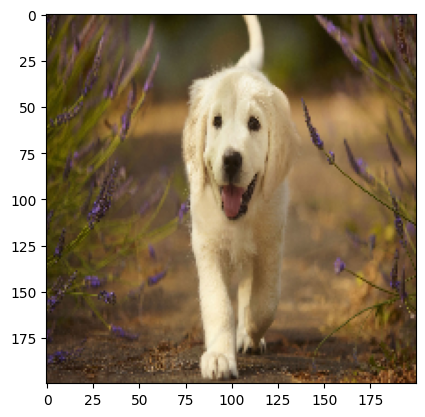

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
Dog


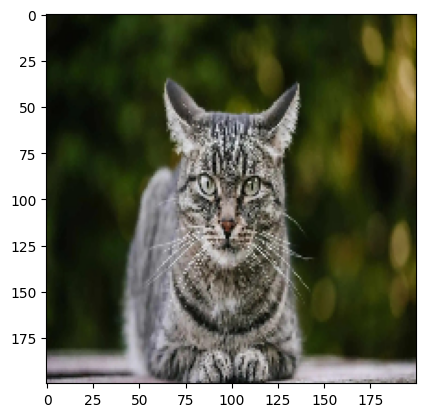

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
cat


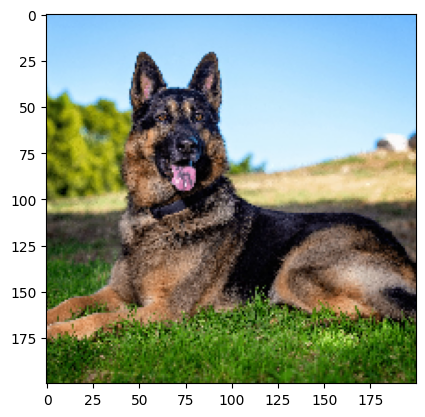

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Dog


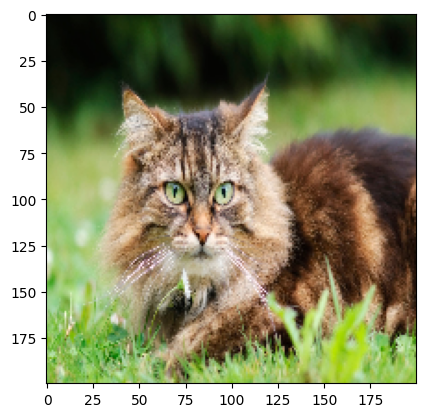

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
cat


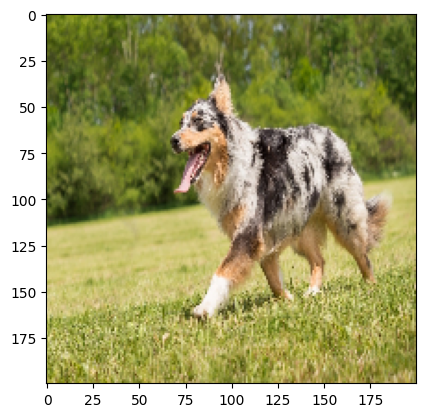

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Dog


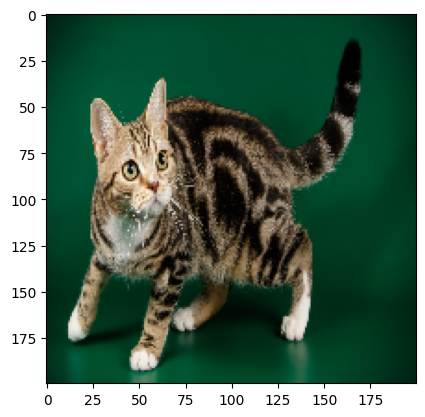

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
cat


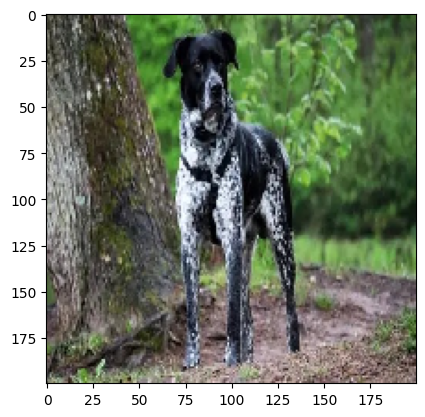

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Dog


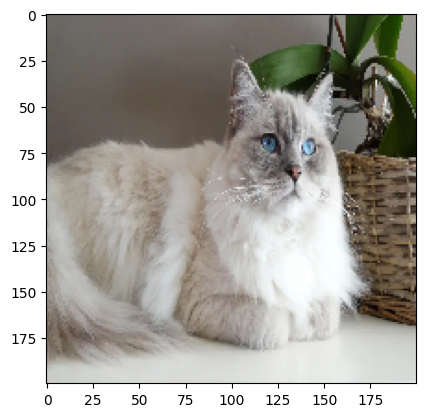

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
cat


In [22]:
path = r"testing"
for i in os.listdir(path):
    img = image.load_img(path+"/"+i,target_size=(200,200))
    plt.imshow(img)
    plt.show()
    
    x = image.img_to_array(img)
    x = np.expand_dims(x,axis = 0)
    pic = np.vstack([x])
    val = model.predict(pic)
    if val==0:
        print("cat")
    else:
        print("Dog")